[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pycroscopy/pycroscopy/blob/main/jupyter_notebooks/PycroscopyDenosingAutoencoder.ipynb)

# Autoencoders for Image Cleaning

*  *Notebook prepared by Maxim Ziatdinov  (email: ziatdinovmax@gmail.com)*

*  *The simulated data (atomic coordinates) comes from MD calculations by Bobby Sumpter and Ayana Ghosh*

*  *Experimental (validation) data by Ondrej Dyck*



---


This notebook provides an example of training a Denoising Autoencoder for simple image cleaning using Pycroscopy's DL module. Generally, autoencoders refer to the class of the neural networks that compress the data set to a small number of bottleneck features, and then expand back to original data size. The training aims to minimize information loss between the initial and reconstructed images via usual backpropagation. This process tends to select the relevant features in the data set and reject the noise, giving rise to applications for denoising.


---







Installation:

In [1]:
!git clone -b phoenix --single-branch https://github.com/pycroscopy/pycroscopy  # To be replaced with pip install once there is a stable version
%cd pycroscopy/

Cloning into 'pycroscopy'...
remote: Enumerating objects: 191, done.
remote: Counting objects: 100% (191/191), done.
remote: Compressing objects: 100% (149/149), done.
remote: Total 21581 (delta 85), reused 129 (delta 31), pack-reused 21390
Receiving objects: 100% (21581/21581), 316.45 MiB | 25.19 MiB/s, done.
Resolving deltas: 100% (15743/15743), done.
/content/pycroscopy


Imports:

In [2]:
import pycroscopy as px
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Down(load) simulated data of graphene:

In [3]:
# Download into VM storage
!wget -O "graphene_MD_imgs.npy" https://www.dropbox.com/s/r2cz8jqc9m19gaj/cropped_images_new.npy?dl=1

--2021-03-19 20:28:05--  https://www.dropbox.com/s/r2cz8jqc9m19gaj/cropped_images_new.npy?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.82.18, 2620:100:6032:18::a27d:5212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.82.18|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /s/dl/r2cz8jqc9m19gaj/cropped_images_new.npy [following]
--2021-03-19 20:28:05--  https://www.dropbox.com/s/dl/r2cz8jqc9m19gaj/cropped_images_new.npy
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uce59d3b2ad3378db72b33aae7ca.dl.dropboxusercontent.com/cd/0/get/BLCNBJ0Xnl5iSQzWVDGB_tHdeklRZFwIRqXtCY-YGuWWp2LJi-3Upd9w97EwlqDIYPrU27tzXOwEJxSqId7v76LYnT2FzMR6yGeJ55DGBE_Fz141iKwafIhCNh3dIW-dNdroU730WNKsMPcSjwDx8uXv/file?dl=1# [following]
--2021-03-19 20:28:06--  https://uce59d3b2ad3378db72b33aae7ca.dl.dropboxusercontent.com/cd/0/get/BLCNBJ0Xnl5iSQzWVDGB_tHdeklRZFwIRqXtCY-YGuWWp2LJi-3Upd9

Load data into the notebook:


In [4]:
imgdata = np.load("graphene_MD_imgs.npy")[::3] # take ~1/3 of the data
print(imgdata.shape)

(2016, 256, 256)


Now let's corrupt our data with noise and then use a denoising autoencoder to reconstruct the original images.

In [5]:
np.random.seed(42) # for reproducibility
# Add noise to data
imgdata_noisy = imgdata + np.random.normal(scale=8, size=imgdata.shape)

View selected pairs of images (images from the left subplot will be inputs into a neural network and images from the right subplot will be our targets)

Text(0.5, 1.0, 'Original image')

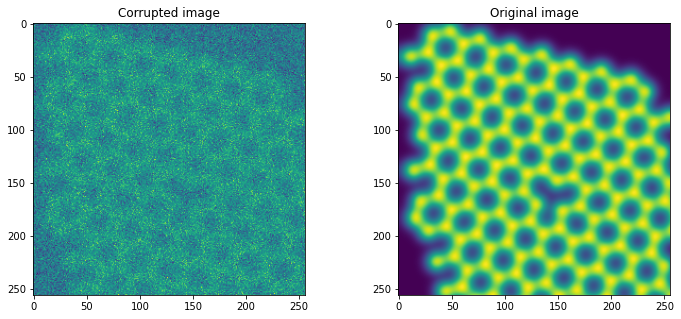

In [6]:
k = 15

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(imgdata_noisy[k])
ax2.imshow(imgdata[k])
ax1.set_title("Corrupted image")
ax2.set_title("Original image")

A neural network takes a 4D tensor (*n_samples, n_channels, height, width*) as an input where the second dimension is a number of channels. This dimension needs to specified explicitly even if you have only one channel (i.e., you are working with grayscale images). This can be easily done using NumPy's ```np.expand_dims(your_array, 1)``` command or just ```your_array[:, None]```.

In [7]:
imgdata = imgdata[:, None]
imgdata_noisy = imgdata_noisy[:, None]

Split model into train and test sets using a standard *sklearn* function:

In [8]:
data_split = train_test_split(imgdata_noisy, imgdata, test_size=0.2, random_state=1)
imgdata_noisy, imgdata_noisy_test, imgdata, imgdata_test = data_split

Initialize our denosing autoencoder:

In [9]:
model = px.learn.dl.models.DenoisingAutoEncoder(ndim=2, batchnorm=False)  # consider setting batchnorm to True if training becomes unstable
print(model)

DenoisingAutoEncoder(
  (encoder): FeatureExtractor(
    (c0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): LeakyReLU(negative_slope=0.01)
        (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (c1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): LeakyReLU(negative_slope=0.01)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): LeakyReLU(negative_slope=0.01)
        (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (c2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): LeakyReLU(negative_slope=0.01)
        (2): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): LeakyReLU(negati

Train it for 20 epochs:

In [10]:
# Initialize trainer
trainer = px.learn.Trainer(
    model, # our initialized model
    imgdata_noisy, imgdata, imgdata_noisy_test, imgdata_test,  # train and test data
    batch_size=64  # batch size
)
# Train for 20 epochs
trainer.fit(num_epochs=20)

Epoch: 1... Training loss: 44.9096... Test loss: 19.9743
Epoch: 2... Training loss: 20.2087... Test loss: 15.6786
Epoch: 3... Training loss: 10.7083... Test loss: 5.4988
Epoch: 4... Training loss: 4.2213... Test loss: 3.2833
Epoch: 5... Training loss: 2.8451... Test loss: 2.3343
Epoch: 6... Training loss: 2.1457... Test loss: 1.7723
Epoch: 7... Training loss: 1.5811... Test loss: 1.3671
Epoch: 8... Training loss: 1.6015... Test loss: 1.1947
Epoch: 9... Training loss: 1.1573... Test loss: 0.9795
Epoch: 10... Training loss: 0.9968... Test loss: 0.9733
Epoch: 11... Training loss: 0.9834... Test loss: 0.9294
Epoch: 12... Training loss: 0.7927... Test loss: 0.7284
Epoch: 13... Training loss: 0.7194... Test loss: 0.7425
Epoch: 14... Training loss: 0.7701... Test loss: 1.1028
Epoch: 15... Training loss: 1.7580... Test loss: 1.4173
Epoch: 16... Training loss: 0.9316... Test loss: 0.7047
Epoch: 17... Training loss: 0.6259... Test loss: 0.5943
Epoch: 18... Training loss: 0.5754... Test loss: 0.5

Plot training/test loss history:

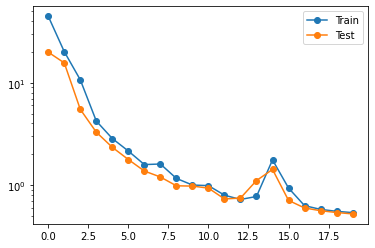

In [11]:
plt.plot(trainer.train_losses, '-o', label='Train')
plt.plot(trainer.test_losses, '-o', label='Test')
plt.yscale("log")
plt.legend();

Use the trained model to clean the test data:

In [12]:
prediction = model.predict(imgdata_noisy_test)

View the predictions:

(note that here we are using the NumPy's ```squeeze``` method to automatically get rid of a single channel dimension in the output)

Text(0.5, 1.0, 'Original image')

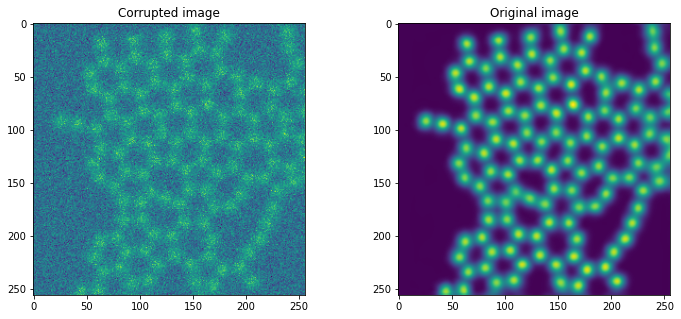

In [13]:
k = 15

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(imgdata_noisy_test[k,0])
ax2.imshow(prediction[k].squeeze())
ax1.set_title("Corrupted image")
ax2.set_title("Original image")

Now we are going to gradually increase the noise level and see how well our model can generalize:

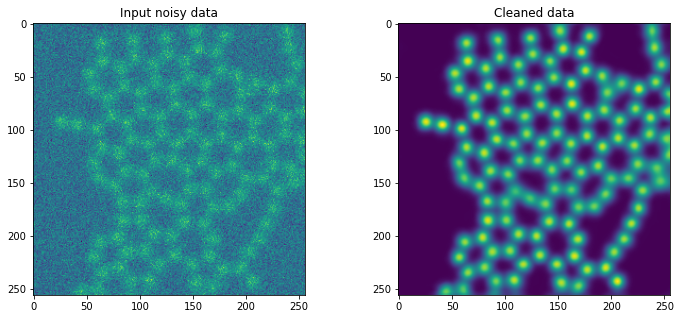

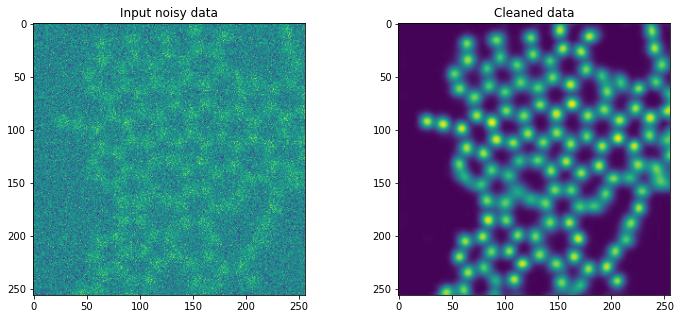

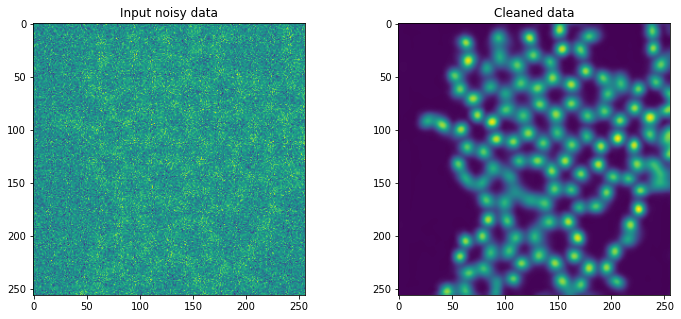

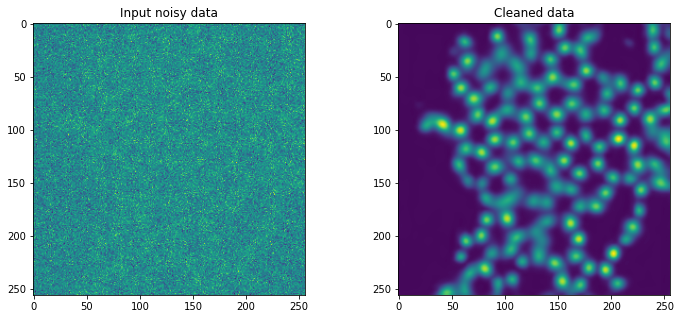

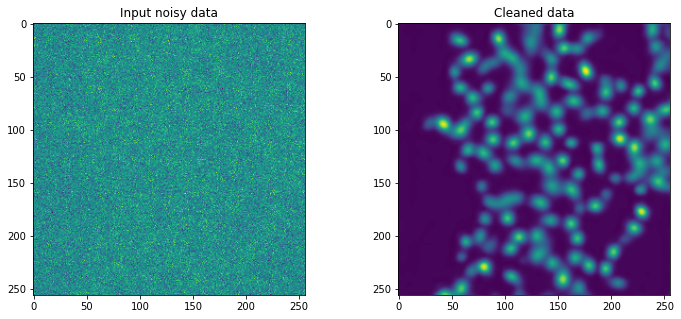

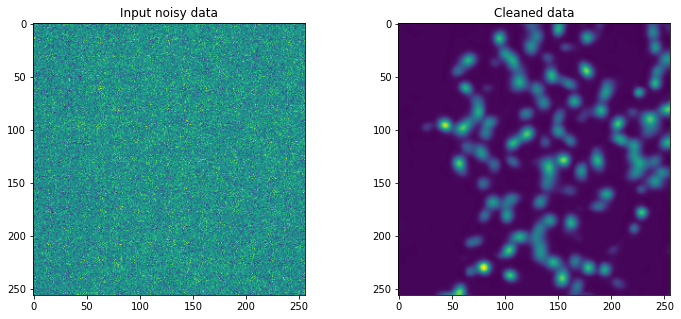

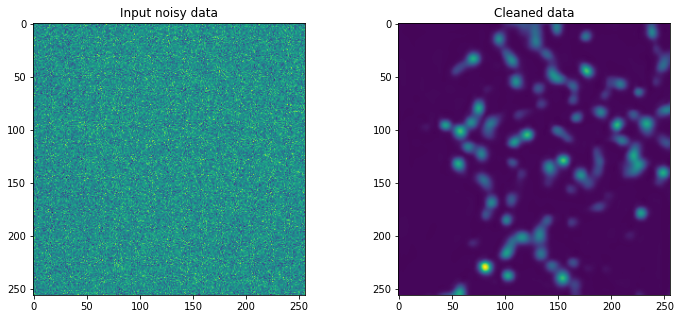

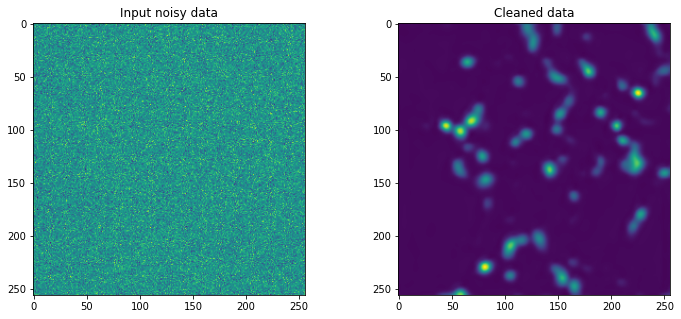

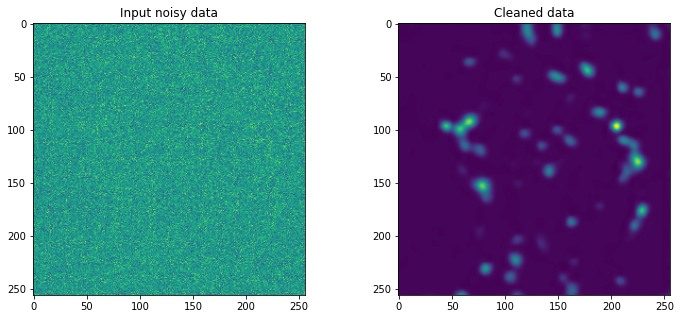

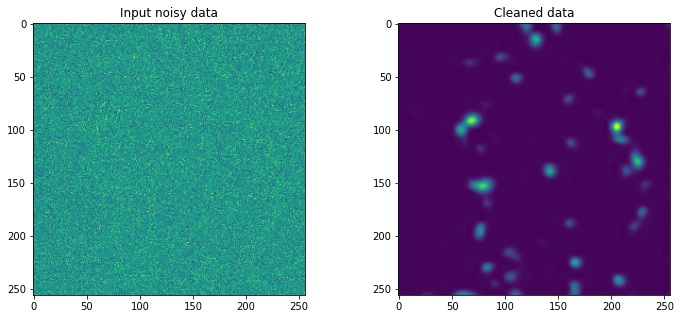

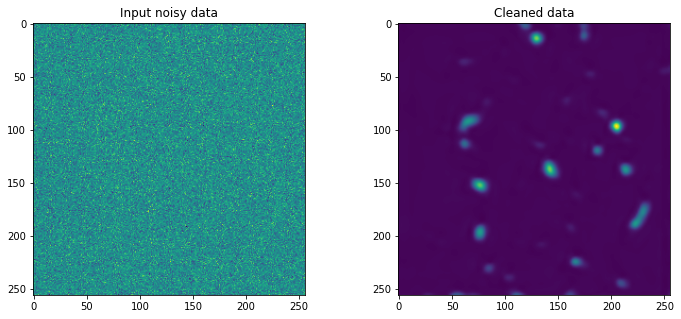

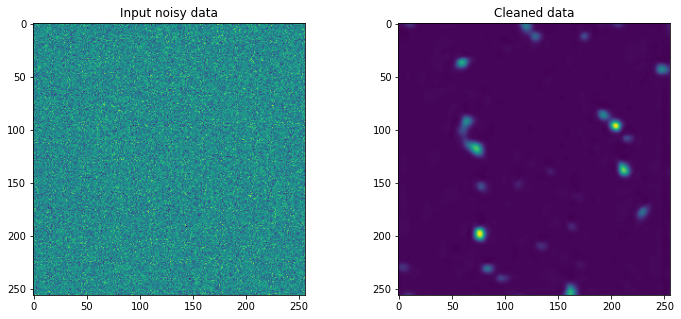

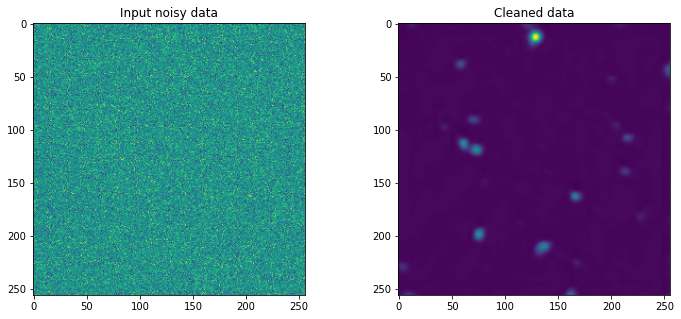

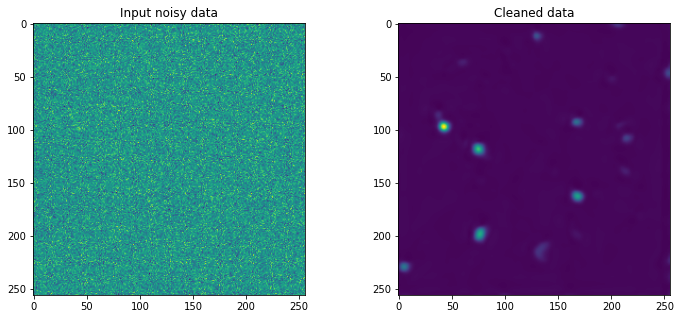

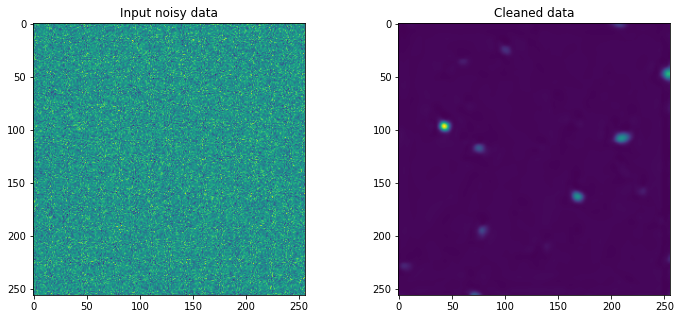

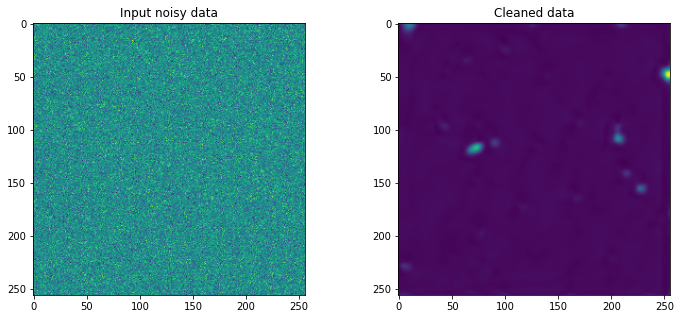

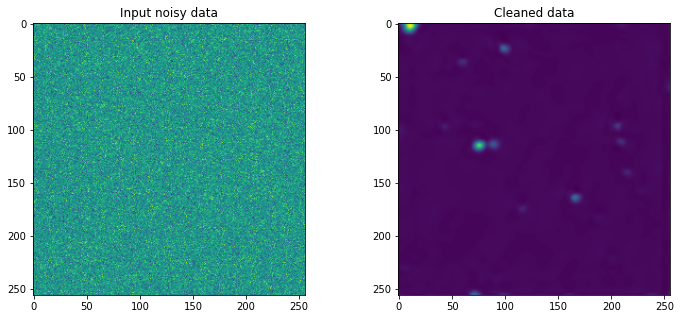

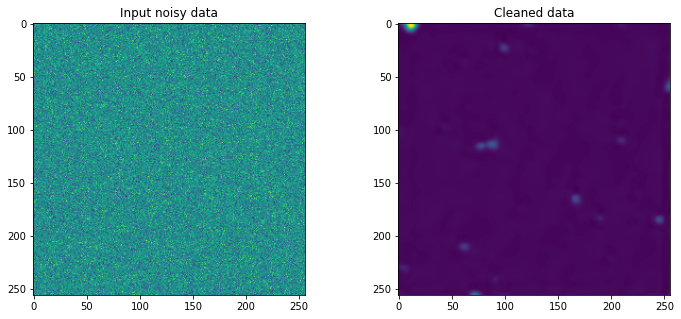

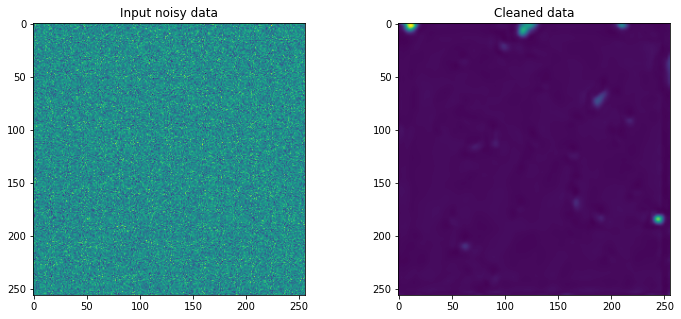

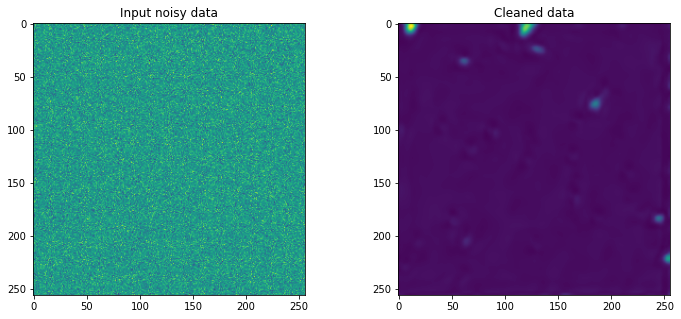

In [14]:
img = imgdata_test[k:k+1]
for s in range(0, 100, 5):
    img = img + np.random.normal(scale=8+s, size=img.shape)
    prediction = model.predict(img)
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.imshow(img[0,0])
    ax2.imshow(prediction.squeeze())
    ax1.set_title("Input noisy data")
    ax2.set_title("Cleaned data")
    plt.show()

Finally, let's apply it to experimental data. Note that the current model is by no means optimized to work with experimental data - we didn't even consider any scale changes. Still, it is interesting to see how it will perform on real-world data.

In [15]:
# download data
!wget -O "graphene_exp.npy" https://www.dropbox.com/s/33uo35z4siiy2y4/Gr_SiCr.npy?dl=1

--2021-03-19 20:32:02--  https://www.dropbox.com/s/33uo35z4siiy2y4/Gr_SiCr.npy?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.82.18, 2620:100:6032:18::a27d:5212
Connecting to www.dropbox.com (www.dropbox.com)|162.125.82.18|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /s/dl/33uo35z4siiy2y4/Gr_SiCr.npy [following]
--2021-03-19 20:32:03--  https://www.dropbox.com/s/dl/33uo35z4siiy2y4/Gr_SiCr.npy
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc74479041c02a0736ceaefb9c17.dl.dropboxusercontent.com/cd/0/get/BLD05JCWkasuivMoW6ZZg4XwGYw8XM0y2U9lSAj78HJSosy_lc5bIb_qxc0IN99foawdpnUmB_YQQq_k6P_IMywQ4TgiQ0sYNy2F03gQlPDYBiy1NRK4oQ0QTjUrZzZ0xN2jcUeoMO2wCFQdo3V97Ovd/file?dl=1# [following]
--2021-03-19 20:32:04--  https://uc74479041c02a0736ceaefb9c17.dl.dropboxusercontent.com/cd/0/get/BLD05JCWkasuivMoW6ZZg4XwGYw8XM0y2U9lSAj78HJSosy_lc5bIb_qxc0IN99foawdpnUmB_YQQq_k6P_IMywQ

In [16]:
expdata = np.load("graphene_exp.npy")
expdata = expdata * 60 # to be within a range of pixel values used in training data

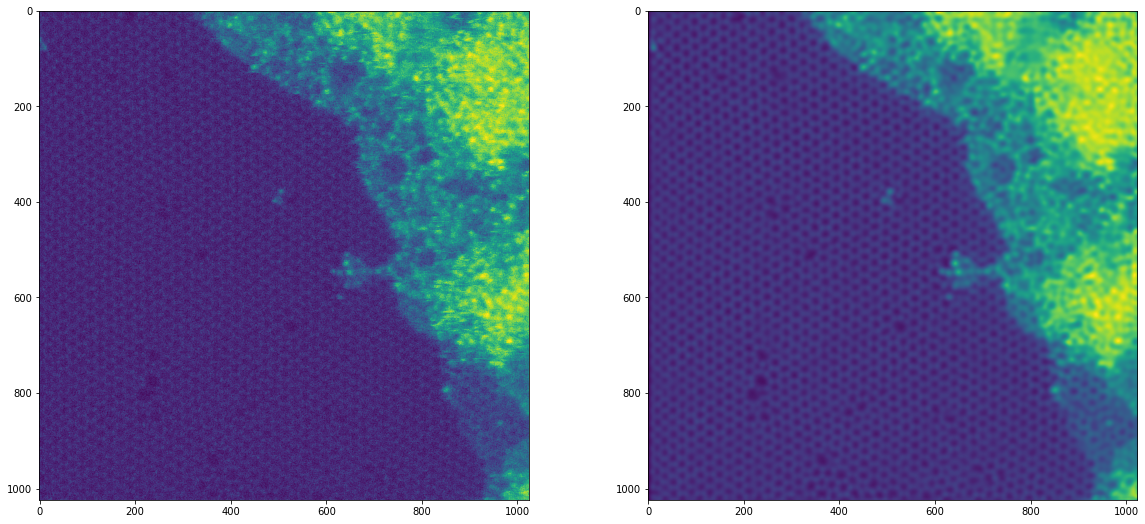

In [17]:
pred = model.predict(expdata[None, None])

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
ax1.imshow(expdata)
ax2.imshow(pred.squeeze());

Looks like a decent result!

## Optional: preserve the full notebook run in Dataerai

Use Dataerai to preserve the raw image arrays, denoised outputs, notebook snapshot, execution log, and provenance links for this denoising tutorial. This opt-in cell creates a notebook-run collection, preserves raw inputs and parameters, derived arrays and files, output images, notebook information, and an execution log. It then links the preserved assets with Dataerai provenance relationships using the Dataerai SDK directly; pycroscopy does not provide a Dataerai wrapper.


In [ ]:
RUN_DATAERAI_DEMO = False
DATAERAI_PROJECT_ID = "<your-project-id>"
DATAERAI_BINARY_PATH = None  # Set to "/usr/local/bin/dataerai" to auto-start the daemon.
DATAERAI_SOURCE_ASSET_IDS = []  # Optional existing Dataerai asset IDs for upstream source data.
DATAERAI_PARENT_COLLECTION_ID = None  # Optional parent collection; defaults to the project root collection.
DATAERAI_COLLECTION_ID = None  # Set this to reuse an existing notebook-run collection.
DATAERAI_COLLECTION_TITLE = "Pycroscopy PycroscopyDenosingAutoencoder notebook run"
DATAERAI_NOTEBOOK_PATH_CANDIDATES = ['PycroscopyDenosingAutoencoder.ipynb', 'jupyter_notebooks/PycroscopyDenosingAutoencoder.ipynb']
DATAERAI_RAW_DATA_PATHS = ['graphene_MD_imgs.npy', 'graphene_exp.npy']
DATAERAI_RESULT_ARRAY_NAMES = ['prediction', 'pred', 'expdata']
DATAERAI_RESULT_PATH = "denoising_autoencoder_prediction.npz"
DATAERAI_ADDITIONAL_OUTPUT_PATHS = []
DATAERAI_OUTPUT_IMAGE_PATHS = []
DATAERAI_PARAMETER_NAMES = ['model', 'trainer']
DATAERAI_TAGS = ['autoencoder', 'denoising', 'pycroscopy']
DATAERAI_OPERATION = "denoising_autoencoder"

if RUN_DATAERAI_DEMO:
    if DATAERAI_PROJECT_ID.startswith("<"):
        raise ValueError("Set DATAERAI_PROJECT_ID before running the Dataerai preservation cell.")

    import hashlib
    import json
    import os
    import platform
    import subprocess
    import sys
    import uuid
    from datetime import datetime, timezone
    from pathlib import Path

    import numpy as np
    import requests
    from dataerai import DataeraiClient, DaemonError
    from dataerai.ml.access import (
        DEFAULT_CRED_PATH,
        bearer_headers,
        load_credentials,
        refresh_token,
        save_credentials,
    )

    run_id = str(uuid.uuid4())
    run_started_at = datetime.now(timezone.utc).isoformat()
    notebook_name = "PycroscopyDenosingAutoencoder.ipynb"
    output_dir = Path("dataerai_preservation") / Path(notebook_name).stem / run_id
    output_dir.mkdir(parents=True, exist_ok=True)

    def _json_safe(value):
        if value is None or isinstance(value, (str, int, float, bool)):
            return value
        if isinstance(value, Path):
            return str(value)
        if isinstance(value, dict):
            return {str(key): _json_safe(item) for key, item in value.items()}
        if isinstance(value, (list, tuple, set)):
            return [_json_safe(item) for item in value]
        if hasattr(value, "item"):
            try:
                return _json_safe(value.item())
            except Exception:
                pass
        if hasattr(value, "tolist"):
            try:
                return _json_safe(value.tolist())
            except Exception:
                pass
        return str(value)

    def _sha256(path):
        digest = hashlib.sha256()
        with Path(path).open("rb") as stream:
            for chunk in iter(lambda: stream.read(1024 * 1024), b""):
                digest.update(chunk)
        return digest.hexdigest()

    def _file_metadata(path):
        p = Path(path)
        return {
            "filename": p.name,
            "path": str(p),
            "suffix": p.suffix,
            "size_bytes": p.stat().st_size,
            "sha256": _sha256(p),
        }

    def _write_json(path, payload):
        Path(path).write_text(json.dumps(_json_safe(payload), indent=2, sort_keys=True) + "\n")
        return Path(path)

    def _existing_paths(paths):
        found = []
        missing = []
        for raw in paths:
            p = Path(raw).expanduser()
            if p.exists() and p.is_file():
                found.append(p)
            else:
                missing.append(str(raw))
        return found, missing

    def _first_existing_path(paths):
        for raw in paths:
            p = Path(raw).expanduser()
            if p.exists() and p.is_file():
                return p
        return None

    def _collect_arrays(names):
        arrays = {}
        for name in names:
            if name not in globals():
                continue
            try:
                value = np.asarray(globals()[name])
            except Exception:
                continue
            if value.dtype == object:
                continue
            arrays[name] = value
        if not arrays:
            raise ValueError("Run the tutorial analysis cells before preserving this artifact.")
        return arrays

    def _collect_parameters(names):
        params = {}
        for name in names:
            if name in globals():
                params[name] = _json_safe(globals()[name])
        return params

    def _package_versions():
        versions = {}
        for package in ("pycroscopy", "sidpy", "numpy", "scipy", "skimage", "sklearn", "matplotlib", "torch", "dataerai"):
            try:
                module = __import__(package)
                versions[package] = getattr(module, "__version__", "unknown")
            except Exception:
                continue
        return versions

    def _git_info():
        try:
            return {
                "commit": subprocess.check_output(["git", "rev-parse", "HEAD"], text=True, stderr=subprocess.DEVNULL).strip(),
                "branch": subprocess.check_output(["git", "rev-parse", "--abbrev-ref", "HEAD"], text=True, stderr=subprocess.DEVNULL).strip(),
                "dirty": bool(subprocess.check_output(["git", "status", "--porcelain"], text=True, stderr=subprocess.DEVNULL).strip()),
            }
        except Exception:
            return {}

    def _ipython_history(limit=200):
        try:
            ip = get_ipython()
        except Exception:
            ip = None
        if ip is None:
            return []
        history = ip.user_ns.get("In", [])
        return [
            {"execution_index": index, "source": source}
            for index, source in list(enumerate(history))[-limit:]
            if source
        ]

    def _save_open_figures(directory):
        saved = []
        try:
            import matplotlib.pyplot as plt
        except Exception:
            return saved
        for number in plt.get_fignums():
            fig = plt.figure(number)
            path = directory / f"{Path(notebook_name).stem}_figure_{number}.png"
            fig.savefig(path, dpi=200, bbox_inches="tight")
            saved.append(path)
        return saved

    def _load_dataerai_credentials():
        raw = os.environ.get("DATAERAI_CREDENTIALS_JSON")
        if raw:
            return json.loads(raw), None
        return load_credentials(), DEFAULT_CRED_PATH

    def _server(creds):
        value = creds.get("server") or creds.get("server_url") or ""
        if not value:
            raise KeyError('credentials missing "server" or "server_url"')
        return value.rstrip("/")

    def _dataerai_request(creds, cred_path, method, path, **kwargs):
        url = f"{_server(creds)}{path}"
        headers = dict(kwargs.pop("headers", {}) or {})
        headers.update(bearer_headers(creds))
        response = requests.request(method, url, headers=headers, timeout=30, **kwargs)
        if response.status_code == 401 and creds.get("refresh_token"):
            creds.update(refresh_token(creds))
            if cred_path is not None:
                save_credentials(creds, cred_path)
            headers.update(bearer_headers(creds))
            response = requests.request(method, url, headers=headers, timeout=30, **kwargs)
        response.raise_for_status()
        if response.content:
            return response.json()
        return None

    def _create_notebook_collection(creds, cred_path):
        if DATAERAI_COLLECTION_ID:
            return {"id": DATAERAI_COLLECTION_ID, "title": DATAERAI_COLLECTION_TITLE}
        payload = {
            "title": f"{DATAERAI_COLLECTION_TITLE} ({run_id[:8]})",
            "description": (
                "Notebook preservation run for pycroscopy. Contains raw inputs, "
                "notebook information, execution log, derived arrays, output files, "
                "output images, and provenance-linked assets."
            ),
            "owner_type": "project",
            "owner_id": DATAERAI_PROJECT_ID,
            "tags": sorted(set([*DATAERAI_TAGS, "notebook-run", "provenance", "pycroscopy"])),
            "type": ["notebook-run", "pycroscopy"],
        }
        if DATAERAI_PARENT_COLLECTION_ID:
            payload["parent_id"] = DATAERAI_PARENT_COLLECTION_ID
        return _dataerai_request(creds, cred_path, "POST", "/api/collections/", json=payload)

    def _add_asset_to_collection(creds, cred_path, collection_id, asset_id, failures):
        try:
            _dataerai_request(
                creds,
                cred_path,
                "POST",
                f"/api/collections/{collection_id}/assets/",
                json={"asset_id": asset_id},
            )
        except Exception as exc:
            failures.append({"asset_id": asset_id, "error": str(exc)})

    def _asset_metadata(role, path, extra=None):
        metadata = {
            "pycroscopy": {
                "schema_version": 2,
                "run_id": run_id,
                "created_at": datetime.now(timezone.utc).isoformat(),
                "notebook": notebook_name,
                "operation": DATAERAI_OPERATION,
                "role": role,
                "file": _file_metadata(path),
                "environment": {
                    "python": sys.version,
                    "platform": platform.platform(),
                    "cwd": str(Path.cwd()),
                    "packages": _package_versions(),
                    "git": _git_info(),
                },
            }
        }
        if extra:
            metadata["pycroscopy"].update(_json_safe(extra))
        return metadata

    def _upload_asset(client, path, role, title, tags, extra_metadata=None):
        uploaded = client.upload(
            str(path),
            title=title,
            owner_type="project",
            owner_id=DATAERAI_PROJECT_ID,
            collection_id=notebook_collection["id"],
            tags=sorted(set([*DATAERAI_TAGS, role, *tags])),
            metadata=_asset_metadata(role, path, extra_metadata),
            transfer_timeout_s=3600,
        )
        return {"asset_id": uploaded.asset_id, "content_id": uploaded.content_id, "path": str(path), "role": role, "title": title}

    def _safe_relationship(client, from_asset_id, to_asset_id, rel_type, relationships, **kwargs):
        if not from_asset_id or not to_asset_id or from_asset_id == to_asset_id:
            return
        try:
            rel = client.create_relationship(from_asset_id, to_asset_id, rel_type, **kwargs)
            relationships.append({"id": rel.id, "type": rel.type, "from_asset_id": rel.from_asset_id, "to_asset_id": rel.to_asset_id})
        except DaemonError as exc:
            if getattr(exc, "code", "") != "ERR_RELATIONSHIP_EXISTS":
                raise
            relationships.append({"type": rel_type, "from_asset_id": from_asset_id, "to_asset_id": to_asset_id, "status": "already_exists"})

    result_arrays = _collect_arrays(DATAERAI_RESULT_ARRAY_NAMES)
    result_path = output_dir / DATAERAI_RESULT_PATH
    np.savez_compressed(result_path, **result_arrays)
    result_summary = {name: {"shape": list(value.shape), "dtype": str(value.dtype)} for name, value in result_arrays.items()}

    raw_paths, missing_raw_paths = _existing_paths(DATAERAI_RAW_DATA_PATHS)
    additional_output_paths, missing_output_paths = _existing_paths(DATAERAI_ADDITIONAL_OUTPUT_PATHS)
    configured_image_paths, missing_image_paths = _existing_paths(DATAERAI_OUTPUT_IMAGE_PATHS)
    generated_image_paths = _save_open_figures(output_dir)
    image_paths = []
    seen_image_paths = set()
    for path in [*configured_image_paths, *generated_image_paths]:
        key = str(path.resolve())
        if key not in seen_image_paths:
            image_paths.append(path)
            seen_image_paths.add(key)

    notebook_path = _first_existing_path(DATAERAI_NOTEBOOK_PATH_CANDIDATES)
    parameters = _collect_parameters(DATAERAI_PARAMETER_NAMES)
    sanitized_source_asset_ids = [asset_id for asset_id in DATAERAI_SOURCE_ASSET_IDS if asset_id and not str(asset_id).startswith("<")]

    raw_manifest_path = _write_json(
        output_dir / "raw_inputs_manifest.json",
        {
            "run_id": run_id,
            "notebook": notebook_name,
            "operation": DATAERAI_OPERATION,
            "source_asset_ids": sanitized_source_asset_ids,
            "raw_data_paths": [_file_metadata(path) for path in raw_paths],
            "missing_raw_data_paths": missing_raw_paths,
            "parameters": parameters,
        },
    )
    notebook_manifest_path = _write_json(
        output_dir / "notebook_manifest.json",
        {
            "run_id": run_id,
            "notebook": notebook_name,
            "notebook_path": str(notebook_path) if notebook_path else None,
            "notebook_file": _file_metadata(notebook_path) if notebook_path else None,
            "path_candidates": DATAERAI_NOTEBOOK_PATH_CANDIDATES,
            "input_history": _ipython_history(),
            "environment": {"packages": _package_versions(), "git": _git_info(), "cwd": str(Path.cwd())},
        },
    )

    creds, cred_path = _load_dataerai_credentials()
    client_kwargs = {} if DATAERAI_BINARY_PATH is None else {"binary_path": DATAERAI_BINARY_PATH}
    with DataeraiClient(**client_kwargs) as client:
        auth_status = client.auth_status()
        notebook_collection = _create_notebook_collection(creds, cred_path)
        collection_failures = []
        for source_asset_id in sanitized_source_asset_ids:
            _add_asset_to_collection(creds, cred_path, notebook_collection["id"], source_asset_id, collection_failures)

        raw_assets = [
            _upload_asset(client, path, "raw_input", f"Raw input: {path.name}", ["raw-input"], {"lineage": {"source_asset_ids": sanitized_source_asset_ids}})
            for path in raw_paths
        ]
        raw_manifest_asset = _upload_asset(
            client,
            raw_manifest_path,
            "raw_input_manifest",
            f"Raw input manifest: {notebook_name}",
            ["raw-input", "manifest"],
            {"lineage": {"source_asset_ids": sanitized_source_asset_ids}, "missing_raw_data_paths": missing_raw_paths},
        )
        notebook_manifest_asset = _upload_asset(
            client,
            notebook_manifest_path,
            "notebook_manifest",
            f"Notebook manifest: {notebook_name}",
            ["notebook", "manifest"],
            {"notebook_path": str(notebook_path) if notebook_path else None},
        )
        notebook_snapshot_asset = None
        if notebook_path:
            notebook_snapshot_asset = _upload_asset(
                client,
                notebook_path,
                "notebook_snapshot",
                f"Notebook snapshot: {notebook_name}",
                ["notebook", "snapshot"],
                {"manifest_asset_id": notebook_manifest_asset["asset_id"]},
            )

        result_asset = _upload_asset(
            client,
            result_path,
            "derived_result",
            "Denoising autoencoder prediction",
            ["derived-result"],
            {"artifact": result_summary, "lineage": {"source_asset_ids": sanitized_source_asset_ids}},
        )
        additional_output_assets = [
            _upload_asset(client, path, "derived_output", f"Derived output: {path.name}", ["derived-output"], {"lineage": {"source_asset_ids": sanitized_source_asset_ids}})
            for path in additional_output_paths
        ]
        image_assets = [
            _upload_asset(client, path, "output_image", f"Output image: {path.name}", ["output-image", "figure"], {"visualizes_asset_id": result_asset["asset_id"]})
            for path in image_paths
        ]

        execution_log_payload = {
            "run_id": run_id,
            "started_at": run_started_at,
            "completed_at": datetime.now(timezone.utc).isoformat(),
            "status": "preserved",
            "authenticated_user": getattr(auth_status, "user_email", None),
            "notebook": notebook_name,
            "operation": DATAERAI_OPERATION,
            "collection": notebook_collection,
            "collection_membership_failures": collection_failures,
            "source_asset_ids": sanitized_source_asset_ids,
            "missing_paths": {
                "raw_data": missing_raw_paths,
                "additional_outputs": missing_output_paths,
                "configured_images": missing_image_paths,
            },
            "assets": {
                "raw_inputs": raw_assets,
                "raw_manifest": raw_manifest_asset,
                "notebook_manifest": notebook_manifest_asset,
                "notebook_snapshot": notebook_snapshot_asset,
                "result": result_asset,
                "additional_outputs": additional_output_assets,
                "images": image_assets,
            },
            "result_summary": result_summary,
            "parameters": parameters,
            "input_history": _ipython_history(),
            "environment": {"python": sys.version, "platform": platform.platform(), "packages": _package_versions(), "git": _git_info()},
        }
        execution_log_path = _write_json(output_dir / "execution_log.json", execution_log_payload)
        execution_log_asset = _upload_asset(
            client,
            execution_log_path,
            "execution_log",
            f"Execution log: {notebook_name}",
            ["execution-log", "notebook"],
            {"records_assets": execution_log_payload["assets"]},
        )

        relationships = []
        notebook_reference_assets = [notebook_manifest_asset]
        if notebook_snapshot_asset:
            notebook_reference_assets.append(notebook_snapshot_asset)
        input_asset_ids = list(dict.fromkeys([*sanitized_source_asset_ids, *[asset["asset_id"] for asset in raw_assets], raw_manifest_asset["asset_id"]]))
        result_like_assets = [result_asset, *additional_output_assets]
        for output_asset in result_like_assets:
            for input_asset_id in input_asset_ids:
                _safe_relationship(
                    client,
                    output_asset["asset_id"],
                    input_asset_id,
                    "derived_from",
                    relationships,
                    analysis_mode="non_destructive",
                    qualifier_note=f"{output_asset['title']} was created by {notebook_name}.",
                    qualifiers={"tool": "pycroscopy", "notebook": notebook_name, "run_id": run_id},
                )
            for notebook_asset in notebook_reference_assets:
                _safe_relationship(client, output_asset["asset_id"], notebook_asset["asset_id"], "generated_by", relationships, qualifiers={"run_id": run_id})
            _safe_relationship(client, output_asset["asset_id"], execution_log_asset["asset_id"], "documented_by", relationships, qualifiers={"run_id": run_id})
        for image_asset in image_assets:
            _safe_relationship(client, image_asset["asset_id"], result_asset["asset_id"], "visualization_of", relationships, qualifiers={"run_id": run_id})
            for notebook_asset in notebook_reference_assets:
                _safe_relationship(client, image_asset["asset_id"], notebook_asset["asset_id"], "generated_by", relationships, qualifiers={"run_id": run_id})
            _safe_relationship(client, image_asset["asset_id"], execution_log_asset["asset_id"], "documented_by", relationships, qualifiers={"run_id": run_id})
        for raw_asset in raw_assets:
            for source_asset_id in sanitized_source_asset_ids:
                _safe_relationship(client, raw_asset["asset_id"], source_asset_id, "copy_of", relationships, qualifiers={"run_id": run_id})
        _safe_relationship(client, execution_log_asset["asset_id"], notebook_manifest_asset["asset_id"], "execution_of", relationships, qualifiers={"run_id": run_id})

    print("Dataerai collection_id:", notebook_collection["id"])
    print("Dataerai result asset_id:", result_asset["asset_id"])
    print("Dataerai execution_log asset_id:", execution_log_asset["asset_id"])
    print("Raw assets preserved:", len(raw_assets), "missing paths:", len(missing_raw_paths))
    print("Output images preserved:", len(image_assets))
    print("Provenance relationships created:", len(relationships))
